In [19]:
import os
import sys

path = os.path.abspath("")
splitted = path.split(os.sep)
user_independent = os.path.join(
    splitted[0] + os.sep, splitted[1], splitted[2], splitted[3]
)
src_path = os.path.join(user_independent, "GitHub", "Photoswitching")
sys.path.append(src_path)

import src.blinking as bl
import src.distributions as dist
import src.emissions as em
import src.fcs as fcs_p
import src.figure as fi
import src.fluorophores as fl
import src.formulas as fo
import src.miscellaneous as mi
import src.network as net
import src.simulation as si
import src.prediction as pr
import src.analysis as an
import src.transitions as tr

import numpy as np
import pandas as pd

%load_ext autoreload
%autoreload 2

import warnings


def custom_warning_format(msg, category, filename, lineno, line=None):
    if line is None:
        import linecache

        line = linecache.getline(filename, lineno)
    return f"WARNING for line: {line} {msg} \n"


warnings.formatwarning = custom_warning_format

In [29]:
fluorophores = fl.construct_fluorophores(name="fluorophore", distance=10, count=2)
fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)
excitation = tr.Transition(
    transition_type=tr.TransitionType.EXCITATION, rate=1e7, fluorophore_ids=[
        0, 1])
fluorescence = tr.Transition(
    transition_type=tr.TransitionType.FLUORESCENT_EMISSION,
    rate=1e9,
    fluorophore_ids=[0, 1],
)
isc = tr.Transition(
    transition_type=tr.TransitionType.INTERSYSTEM_CROSSING_ST, 
    rate=1e10, 
    fluorophore_ids=[0, 1]
)
isc_2 = tr.Transition(
    transition_type=tr.TransitionType.INTERSYSTEM_CROSSING_TS, 
    rate=1e4, 
    fluorophore_ids=[1, 0]
)
tfret = tr.Transition(
    transition_type=tr.TransitionType.S_T_ANNIHILATION,
    rate=5e9,
    fluorophore_ids=[(0, 1), (1, 0)],
)
transitions = {
    "fluorophore": [excitation, fluorescence, isc, isc_2],
    "D: fluorophore, A: fluorophore, dist: 10.0": [tfret],
}

transition_set = tr.TransitionSet(transitions, fluorophore_system, keep_zero_rates=True)
transition_set.finalize()

WARNING for line:             warnings.warn(
 Fluorophore fluorophore not known. Parameters have to be defined manually. 


In [20]:
fluorophores = fl.construct_fluorophores(name='cy5_widengren',
                                         distance=10,
                                         count=3,
                                         shape='square')
fluorophore_system = fl.FluorophoreSystem(fluorophores)

In [21]:
transitions = fluorophore_system.load_transitions(energy_transfer=True,
                                                  bleaching=True)

In [22]:
transition_set = tr.TransitionSet(transitions, fluorophore_system)

In [23]:
transition_set.finalize()

In [30]:
transition_set.combined_state_transitions_df

,initial_state,final_state,fluorophore_ids,abbreviation,transition_id,rate,photon
id,,,,,,,
0,"(0, 0)","(0, 1)",[1],EXC,0,1.000000e+07,False
1,"(0, 0)","(1, 0)",[0],EXC,0,1.000000e+07,False
2,"(0, 1)","(1, 1)",[0],EXC,0,1.000000e+07,False
3,"(0, 3)","(1, 3)",[0],EXC,0,1.000000e+07,False
4,"(1, 0)","(1, 1)",[1],EXC,0,1.000000e+07,False
5,"(3, 0)","(3, 1)",[1],EXC,0,1.000000e+07,False
6,"(0, 1)","(0, 0)",[1],FLU,1,1.000000e+09,True
7,"(1, 0)","(0, 0)",[0],FLU,1,1.000000e+09,True
8,"(1, 1)","(0, 1)",[0],FLU,1,1.000000e+09,True


In [32]:
simmul = si.Simulation(transition_set)
simmul.run(end_time=10)

In [33]:
analysis = an.Analysis(simmul)

In [34]:
analysis.mean_lifetimes

{'fluorophore': array([9.99890284e-08, 6.25052018e-11, 9.96444853e-05])}

In [8]:
simmul.time_series

array([0.00000000e+00, 3.63935238e-07, 3.64196661e-07, ...,
       3.05506895e-02, 3.05506916e-02, 1.00000000e+01])

In [9]:
emis = em.Emissions(frame_time='1ms')

In [10]:
emis.extract(simmul)

In [11]:
emis.event_time_series

0.000     786
0.001     732
0.002     756
0.003     827
0.004     757
         ... 
9.996       0
9.997       0
9.998       0
9.999       0
10.000      0
Length: 10001, dtype: int64

In [13]:
emis.simulate(transition_set, frames=100)

In [14]:
emis.event_time_series

0.000    794
0.001    762
0.002    763
0.003    755
0.004    770
        ... 
0.095    402
0.096    387
0.097    382
0.098    448
0.099    339
Length: 100, dtype: int64

In [19]:
transition_set = transition_set.filter_by_identity([2])

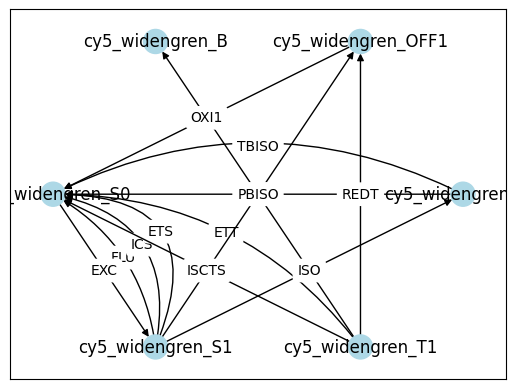

In [20]:
transition_set.plot()

In [21]:
transition_set.single_states

{'cy5_widengren': array([0, 1, 3, 6, 7, 5])}

In [12]:
transition_set.transition_df

transition_type abbreviation  \
Fluorophore   identity                                                        
cy5_widengren 0                      TransitionType.EXCITATION          EXC   
              1            TransitionType.FLUORESCENT_EMISSION          FLU   
              2         TransitionType.INTERSYSTEM_CROSSING_ST        ISCST   
              3         TransitionType.INTERSYSTEM_CROSSING_TS        ISCTS   
              4                   TransitionType.ISOMERIZATION          ISO   
              5                      TransitionType.PHOTO_BISO        PBISO   
              6                      TransitionType.THERM_BISO        TBISO   
              7           TransitionType.INTERNAL_CONVERSION_S          ICS   
              8                      TransitionType.ET_CYCLE_T          ETT   
              9                      TransitionType.ET_CYCLE_S          ETS   
              10                    TransitionType.REDUCTION_T         REDT   
              11                    TransitionType.REDUCTION_S         REDS   
              12                    TransitionType.OXIDATION_1         OXI1   

                           initial_state       final_state          rate  \
Fluorophore   identity                                                     
cy5_widengren 0           SingleState.S0    SingleState.S1  1.946561e+06   
              1           SingleState.S1    SingleState.S0  2.700000e+08   
              2           SingleState.S1    SingleState.T1  8.300000e+05   
              3           SingleState.T1    SingleState.S0  5.000000e+05   
              4           SingleState.S1   SingleState.Cis  2.000000e+07   
              5          SingleState.Cis    SingleState.S0  1.026960e+05   
              6          SingleState.Cis    SingleState.S0  5.000000e+03   
              7           SingleState.S1    SingleState.S0  7.091700e+08   
              8           SingleState.T1    SingleState.S0  1.300000e+06   
              9           SingleState.S1    SingleState.S0  1.300000e+07   
              10          SingleState.T1  SingleState.OFF1  1.300000e+03   
              11          SingleState.S1  SingleState.OFF1  1.300000e+04   
              12        SingleState.OFF1    SingleState.S0  2.000000e-02   

                        photon fluorophore_ids  absorbing  
Fluorophore   identity                                     
cy5_widengren 0          False          [0, 1]      False  
              1           True          [0, 1]      False  
              2          False          [0, 1]      False  
              3          False          [0, 1]      False  
              4          False          [0, 1]      False  
              5          False          [0, 1]      False  
              6          False          [0, 1]      False  
              7          False          [0, 1]      False  
              8          False          [0, 1]      False  
              9          False          [0, 1]      False  
              10         False          [0, 1]      False  
              11         False          [0, 1]      False  
              12         False          [0, 1]      False

In [11]:
dataframe = pd.read_csv(r"C:\Users\vie43sq\OneDrive - Universität Würzburg\GitHub\Photoswitching\src\fluorophore_collection\cy5_data\absorption_off.csv", index_col=0)

In [12]:
dataframe['y'] = dataframe['y'] / 100

In [13]:
dataframe.to_csv(r"C:\Users\vie43sq\OneDrive - Universität Würzburg\GitHub\Photoswitching\src\fluorophore_collection\cy5_data\absorption_off_adj.csv")